# Dark Kinase Multi-Class Classifier

Fine-tunes PubMedBERT to classify PTM text descriptions into 4 classes:

| Class | Label | Criteria |
|-------|-------|----------|
| 0 | Direct phosphorylation (light kinase) | Has phospho prefix + amino acid + specific residue location |
| 1 | Potential dark kinase | Has any 2 of the 3 criteria |
| 2 | Dark kinase | Has only 1 of the 3 criteria (vague phosphorylation mention) |
| 3 | Not a phosphorylation event | None of the 3 criteria present |

In [1]:
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from torch.nn import CrossEntropyLoss
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


## 1. Load data and apply rule-based labeling

In [2]:
df = pd.read_csv("dark_kinome_ptms.csv")
print("Raw dataset shape:", df.shape)
print("\nOriginal output_class distribution (1=bait, 2=prey):")
print(df["output_class"].value_counts().sort_index())


# --- Rule-based labeling heuristics ---
# Three criteria for phosphorylation evidence:
#   1. Phospho prefix  (e.g. "phosphorylated", "phosphorylation")
#   2. Amino acid type  (Tyr / Ser / Thr or full names)
#   3. Specific residue location  (e.g. Tyr-105, Ser-750, S750)


def has_phospho_prefix(text: str) -> bool:
    return bool(re.search(r"(?i)phospho", text))


def has_amino_acid(text: str) -> bool:
    return bool(re.search(r"(?i)\b(Tyr|Ser|Thr|Tyrosine|Serine|Threonine)\b", text))


def has_residue_location(text: str) -> bool:
    return bool(re.search(r"(?i)\b(Tyr|Ser|Thr|Y|S|T)-?\d+\b", text))


def assign_label(text: str) -> int:
    """Assign 4-class label based on phosphorylation evidence criteria."""
    score = (
        int(has_phospho_prefix(text))
        + int(has_amino_acid(text))
        + int(has_residue_location(text))
    )
    if score == 3:
        return 0  # Direct phosphorylation (light kinase)
    elif score == 2:
        return 1  # Potential dark kinase
    elif score == 1:
        return 2  # Dark kinase
    else:
        return 3  # Not a phosphorylation event


df["label"] = df["ptm_text"].apply(assign_label)

CLASS_NAMES = [
    "Direct Phosphorylation",
    "Potential Dark Kinase",
    "Dark Kinase",
    "Not Phosphorylation",
]

print("\nMulti-class label distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (df["label"] == i).sum()
    print(f"  {i} — {name}: {count}")

print("\nSample entries per class:")
for i, name in enumerate(CLASS_NAMES):
    print(f"\n--- Class {i}: {name} ---")
    samples = df[df["label"] == i]["ptm_text"].head(2)
    for s in samples:
        print(f"  {s[:120]}")


Raw dataset shape: (1077, 8)

Original output_class distribution (1=bait, 2=prey):
output_class
1    628
2    449
Name: count, dtype: int64

Multi-class label distribution:
  0 — Direct Phosphorylation: 362
  1 — Potential Dark Kinase: 66
  2 — Dark Kinase: 301
  3 — Not Phosphorylation: 348

Sample entries per class:

--- Class 0: Direct Phosphorylation ---
  Phosphorylated on one or more of the four Ser/Thr residues (Ser-43, Thr-49, Ser-52 or Ser-53). Ser-53 phosphorylation si
  Phosphorylated by CDK2/CCNA1 and CDK2/CCNE1 on Thr-555 in vitro. Also phosphorylated on Thr-555 and Ser-687 in vivo

--- Class 1: Potential Dark Kinase ---
  Phosphorylated on tyrosine residues
  Phosphorylated at tyrosine redidues in response to epidermal growth factor (EGF) (PubMed:19332538, PubMed:7542259). This

--- Class 2: Dark Kinase ---
  Phosphorylated by NFATC-kinase; dephosphorylated by calcineurin
  Hyperphosphorylated during the G1/S phase transition

--- Class 3: Not Phosphorylation ---
  Monoub

## 2. Train / Validation / Test split

In [3]:
# Keep only the columns needed for modeling
model_df = df[["ptm_text", "label"]].copy()

# 80 / 10 / 10 split, stratified by label
train_val_df, test_df = train_test_split(
    model_df,
    test_size=0.10,
    random_state=42,
    stratify=model_df["label"],
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.111,  # 0.111 of 90% ≈ 10% of total
    random_state=42,
    stratify=train_val_df["label"],
)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")
print("\nTrain label distribution:")
for i, name in enumerate(CLASS_NAMES):
    count = (train_df["label"] == i).sum()
    print(f"  {i} — {name}: {count}")


Train: 861  |  Val: 108  |  Test: 108

Train label distribution:
  0 — Direct Phosphorylation: 290
  1 — Potential Dark Kinase: 52
  2 — Dark Kinase: 241
  3 — Not Phosphorylation: 278


## 3. Tokenization with PubMedBERT

In [4]:
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Quick sanity check
sample = model_df["ptm_text"].iloc[0]
tokens = tokenizer(sample, truncation=True, max_length=512)
print("Sample text:", sample[:80], "...")
print("Number of tokens:", len(tokens["input_ids"]))


Sample text: Monoubiquitinated by CBL and CBLB after EGF stimulation; probably on its C-termi ...
Number of tokens: 20


In [5]:
def tokenize(examples):
    return tokenizer(
        examples["ptm_text"],
        truncation=True,
        padding="max_length",
        max_length=512,
    )


# Convert to HuggingFace Datasets
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Tokenize
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Rename label column for HuggingFace Trainer
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

print("Tokenization complete.")
print("Train dataset features:", train_dataset.features)


Map:   0%|          | 0/861 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Tokenization complete.
Train dataset features: {'ptm_text': Value('large_string'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


## 4. Class weights and weighted trainer

In [6]:
# Inverse-frequency class weights: weight_i = N_total / (N_classes * N_i)
NUM_CLASSES = 4
total = len(train_df)
class_counts = train_df["label"].value_counts().sort_index()

weights = []
for i in range(NUM_CLASSES):
    n_i = class_counts.get(i, 1)
    w = total / (NUM_CLASSES * n_i)
    weights.append(w)
    print(f"Class {i} ({CLASS_NAMES[i]}): count={n_i}, weight={w:.3f}")

class_weights = torch.tensor(weights, dtype=torch.float)


class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "precision_macro": precision_score(labels, predictions, average="macro"),
        "recall_macro": recall_score(labels, predictions, average="macro"),
    }


Class 0 (Direct Phosphorylation): count=290, weight=0.742
Class 1 (Potential Dark Kinase): count=52, weight=4.139
Class 2 (Dark Kinase): count=241, weight=0.893
Class 3 (Not Phosphorylation): count=278, weight=0.774


## 5. Load model (4-class head)

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = model.to(device)

print("Model loaded and moved to:", device)
print("Total parameters:", f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f} M")
print("Classification head output size:", model.classifier.out_features)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- 

Model loaded and moved to: mps
Total parameters: 109.5 M
Classification head output size: 4


## 6. Training

In [8]:
training_args = TrainingArguments(
    output_dir="./dkinase_multiclass_model",
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_dir="./logs_multiclass",
    logging_steps=10,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()
print("Training complete.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro
1,0.922037,0.708497,0.861111,0.854020,0.858440,0.898276,0.830952
2,0.156725,0.174355,0.972222,0.961113,0.971888,0.977866,0.947619
3,0.021472,0.070463,0.981481,0.984435,0.981419,0.986486,0.983333
4,0.012528,0.057873,0.981481,0.984435,0.981419,0.986486,0.983333
5,0.004233,0.026525,0.990741,0.992242,0.990727,0.993056,0.991667
6,0.002743,0.028604,0.990741,0.992242,0.990727,0.993056,0.991667
7,0.011879,0.029586,0.990741,0.992242,0.990727,0.993056,0.991667
8,0.003128,0.030975,0.990741,0.992242,0.990727,0.993056,0.991667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete.


## 7. Evaluation on held-out test set

Evaluating on held-out test set...



                        precision    recall  f1-score   support

Direct Phosphorylation       1.00      1.00      1.00        36
 Potential Dark Kinase       1.00      1.00      1.00         7
           Dark Kinase       1.00      1.00      1.00        30
   Not Phosphorylation       1.00      1.00      1.00        35

              accuracy                           1.00       108
             macro avg       1.00      1.00      1.00       108
          weighted avg       1.00      1.00      1.00       108



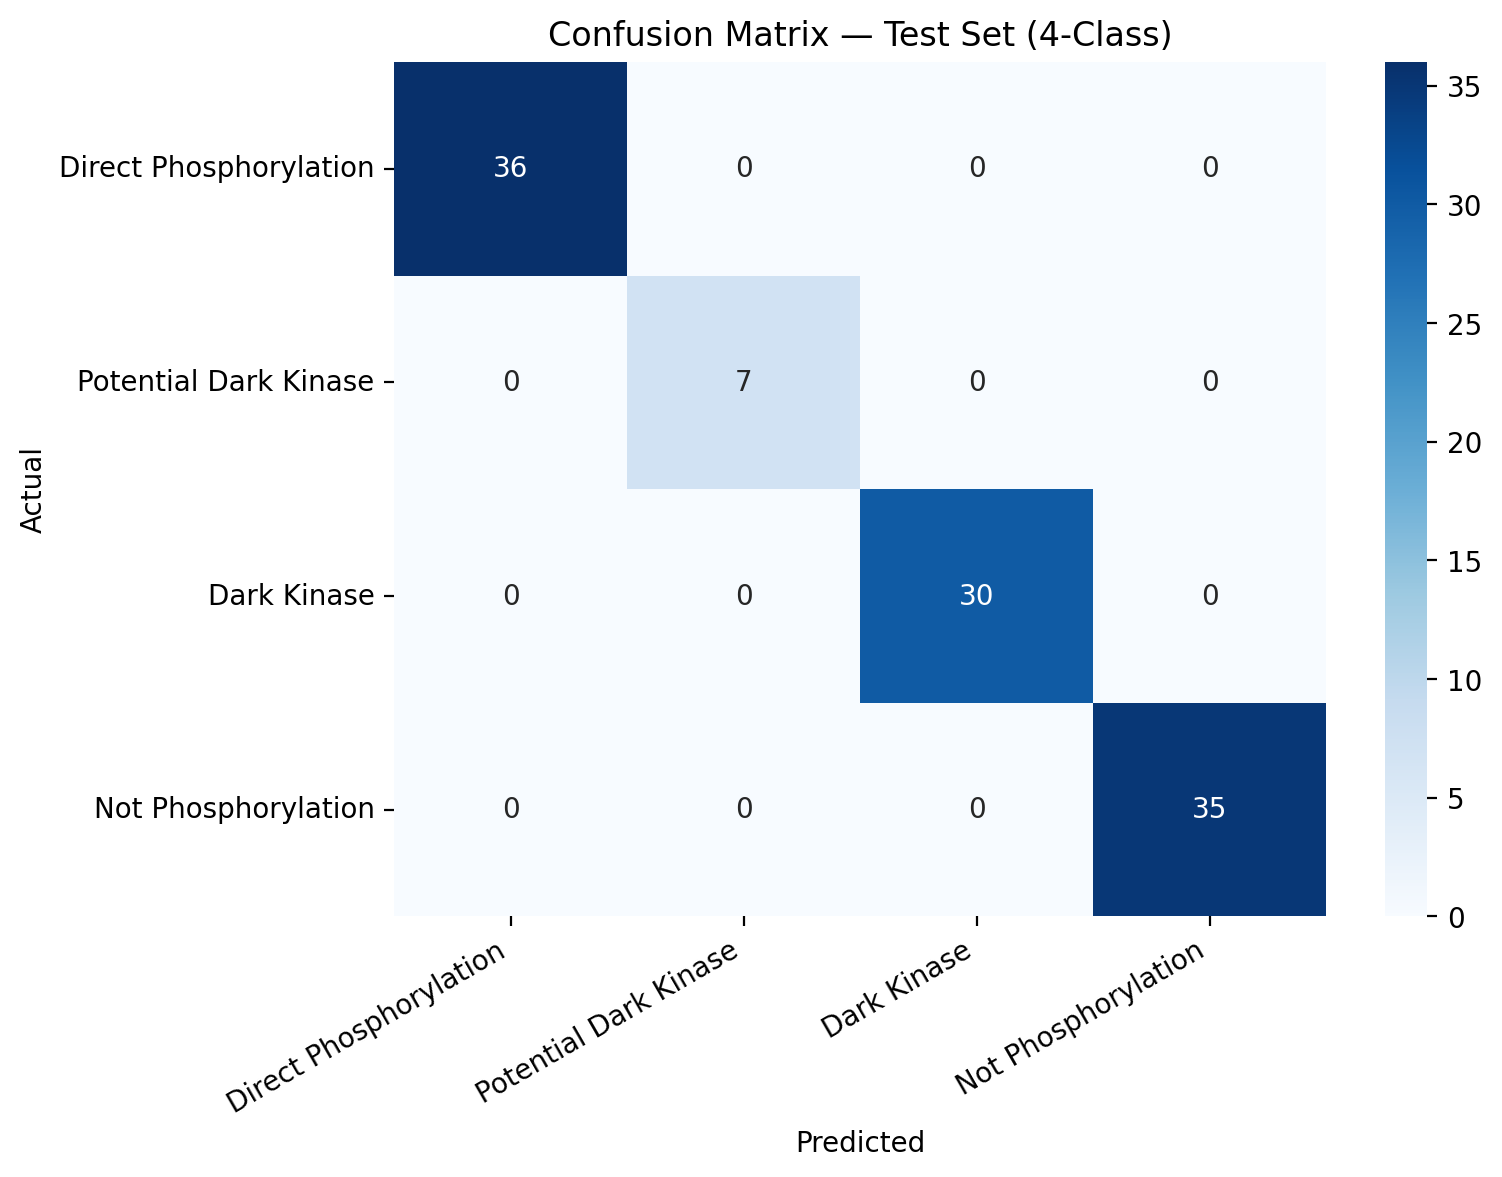

In [9]:
print("Evaluating on held-out test set...\n")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

print(classification_report(labels, preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set (4-Class)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
## 0 shot with PubMedBERT

# Bio-Mistral
# Stratified test-train split



## 8. Save model

In [10]:
trainer.save_model("./dkinase_multiclass_final")
tokenizer.save_pretrained("./dkinase_multiclass_final")
print("Model saved to ./dkinase_multiclass_final")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./dkinase_multiclass_final


## 9. Interactive prediction

In [ ]:
def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred = np.argmax(probs)
    print(f"Prediction: {CLASS_NAMES[pred]}")
    print(f"Confidence: {probs[pred] * 100:.1f}%")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  P({name}): {probs[i] * 100:.1f}%")
    print()


# Test examples spanning all 4 classes
print("=== Direct phosphorylation (all 3 criteria) ===")
predict("Phosphorylated by TBK1 at Ser-172, which activates the kinase")

print("=== Potential dark kinase (2 criteria: phospho + amino acid, no residue) ===")
predict("Phosphorylated on tyrosine residues")

print("=== Dark kinase (1 criterion: just phospho prefix) ===")
predict("Phosphorylated")

print("=== Not phosphorylation ===")
predict("Ubiquitinated by STUB1/CHIP, leading to proteasomal degradation")


=== Direct phosphorylation (all 3 criteria) ===
Prediction: Direct Phosphorylation
Confidence: 99.8%
  P(Direct Phosphorylation): 99.8%
  P(Potential Dark Kinase): 0.1%
  P(Dark Kinase): 0.1%
  P(Not Phosphorylation): 0.0%

=== Potential dark kinase (2 criteria: phospho + amino acid, no residue) ===
Prediction: Potential Dark Kinase
Confidence: 99.8%
  P(Direct Phosphorylation): 0.1%
  P(Potential Dark Kinase): 99.8%
  P(Dark Kinase): 0.1%
  P(Not Phosphorylation): 0.1%

=== Dark kinase (1 criterion: just phospho prefix) ===
Prediction: Dark Kinase
Confidence: 99.8%
  P(Direct Phosphorylation): 0.1%
  P(Potential Dark Kinase): 0.1%
  P(Dark Kinase): 99.8%
  P(Not Phosphorylation): 0.0%

=== Not phosphorylation ===
Prediction: Not Phosphorylation
Confidence: 99.8%
  P(Direct Phosphorylation): 0.1%
  P(Potential Dark Kinase): 0.1%
  P(Dark Kinase): 0.1%
  P(Not Phosphorylation): 99.8%



: 